This assignment is used to show relationship between MLB payroll and team performance overall

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



The data set uses Team.csv which has team stats and salaries.csv which contains salaries per team 

In [37]:
teams = pd.read_csv("Teams.csv")
#sal = salaries
sal = pd.read_csv("Salaries.csv")

In [38]:
#Checks to confirm data size(mainly to see if importing file correctly)
print("Teams size:", teams.shape)
print("Salaries size:", sal.shape)

Teams size: (2805, 48)
Salaries size: (25575, 5)


In [39]:
#Prints dataset for teams
teams.head()

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,NaN,BS1,BNA,NaN,3,31,NaN,20,10,...,NaN,0.83,Boston Red Stockings,South End Grounds I,NaN,103,98,BOS,BS1,BS1
1,1871,NaN,CH1,CNA,NaN,2,28,NaN,19,9,...,NaN,0.82,Chicago White Stockings,Union Base-Ball Grounds,NaN,104,102,CHI,CH1,CH1
2,1871,NaN,CL1,CFC,NaN,8,29,NaN,10,19,...,NaN,0.81,Cleveland Forest Citys,National Association Grounds,NaN,96,100,CLE,CL1,CL1
3,1871,NaN,FW1,KEK,NaN,7,19,NaN,7,12,...,NaN,0.80,Fort Wayne Kekiongas,Hamilton Field,NaN,101,107,KEK,FW1,FW1
4,1871,NaN,NY2,NNA,NaN,5,33,NaN,16,17,...,NaN,0.83,New York Mutuals,Union Grounds (Brooklyn),NaN,90,88,NYU,NY2,NY2


In [40]:
#Prints dataset for salaries
sal.head()

,yearID,teamID,lgID,playerID,salary
0,1985,ATL,NL,barkele01,870000
1,1985,ATL,NL,bedrost01,550000
2,1985,ATL,NL,benedbr01,545000
3,1985,ATL,NL,campri01,633333
4,1985,ATL,NL,ceronri01,625000


In [41]:
print(teams.columns.tolist())

['yearID', 'lgID', 'teamID', 'franchID', 'divID', 'Rank', 'G', 'Ghome', 'W', 'L', 'DivWin', 'WCWin', 'LgWin', 'WSWin', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF', 'RA', 'ER', 'ERA', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA', 'E', 'DP', 'FP', 'name', 'park', 'attendance', 'BPF', 'PPF', 'teamIDBR', 'teamIDlahman45', 'teamIDretro']


In [42]:
print(sal.columns.tolist())

['yearID', 'teamID', 'lgID', 'playerID', 'salary']


This will give us total team salary adding up all the player salaries for a given year to directly compare team salary with performance

In [43]:
teampay = sal.groupby(["yearID", "teamID"])["salary"].sum().reset_index()
teampay.head()

,yearID,teamID,salary
0,1985,ATL,14807000
1,1985,BAL,11560712
2,1985,BOS,10897560
3,1985,CAL,14427894
4,1985,CHA,9846178


In [44]:
print("Teampay size: ",teampay.shape)

Teampay size:  (888, 3)


In [45]:
teamsShrunk = teams[["yearID", "teamID", "W", "L", "R", "RA", "ERA"]].copy()
teamsShrunk.head()

,yearID,teamID,W,L,R,RA,ERA
0,1871,BS1,20,10,401,303,3.55
1,1871,CH1,19,9,302,241,2.76
2,1871,CL1,10,19,249,341,4.11
3,1871,FW1,7,12,137,243,5.17
4,1871,NY2,16,17,302,313,3.72


The team performance and total payroll were merged based on teamID and yearID to allow for direct comparison of performance vs payroll and also to ensure for correct year and team

In [46]:
df = pd.merge(teamsShrunk, teampay, on=["yearID", "teamID"], how = "inner")
print("Merged size: ", df.shape)
df.head()

Merged size:  (888, 8)


,yearID,teamID,W,L,R,RA,ERA,salary
0,1985,ATL,66,96,632,781,4.19,14807000
1,1985,BAL,83,78,818,764,4.38,11560712
2,1985,BOS,81,81,800,720,4.06,10897560
3,1985,CAL,90,72,732,703,3.91,14427894
4,1985,CHA,85,77,736,720,4.07,9846178


We limit down the team and salaries files into the specific columns needed for the summarization

In [47]:
df["run_diff"] = df["R"] - df["RA"]
df.head()

,yearID,teamID,W,L,R,RA,ERA,salary,run_diff
0,1985,ATL,66,96,632,781,4.19,14807000,-149
1,1985,BAL,83,78,818,764,4.38,11560712,54
2,1985,BOS,81,81,800,720,4.06,10897560,80
3,1985,CAL,90,72,732,703,3.91,14427894,29
4,1985,CHA,85,77,736,720,4.07,9846178,16


In [48]:
df.isnull().sum()

yearID      0
teamID      0
W           0
L           0
R           0
RA          0
ERA         0
salary      0
run_diff    0
dtype: int64

This will check for missing values but none were returned so don't need to remove empty rows

In [49]:
df.duplicated().sum()

0

checked for duplications or any column that had null information in it that might throw off the clustering later on

In [50]:
df = df[df["yearID"] >= 1990]
print(df.shape)

(758, 9)


This limits our data set from 1990 onward to not allow for earlier salaries being much smaller interfering with modern salaries  allowing for consistancy with the analysis cutitng off earlier year branches

payorll isnt adjusted for inflation. This means earlier years is not directly comparable to similar values in newer seasons this is a limitation and might can later be adjusted and added before this next section

Data analysis was done to understand the distribution of payrolls to performance variables and identify their relationship to success

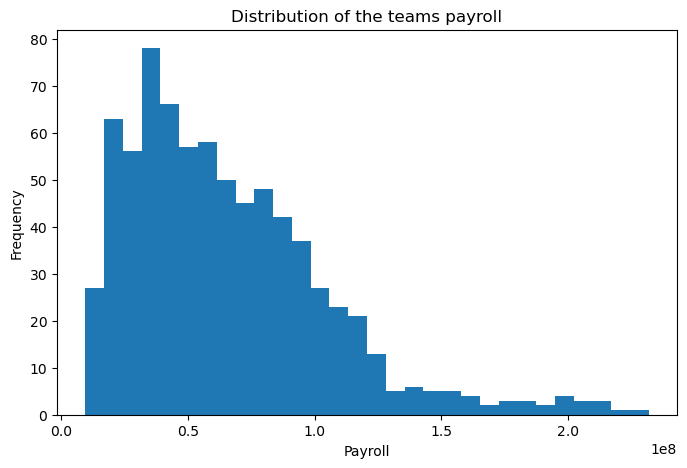

In [51]:
plt.figure(figsize = (8,5))
plt.hist(df["salary"], bins=30)
plt.title("Distribution of the teams payroll")
plt.xlabel("Payroll")
plt.ylabel("Frequency")
plt.show()

The payroll distribution shows many of the teams fall in mid range area while smaller amount of teams have majorly massive payrolls

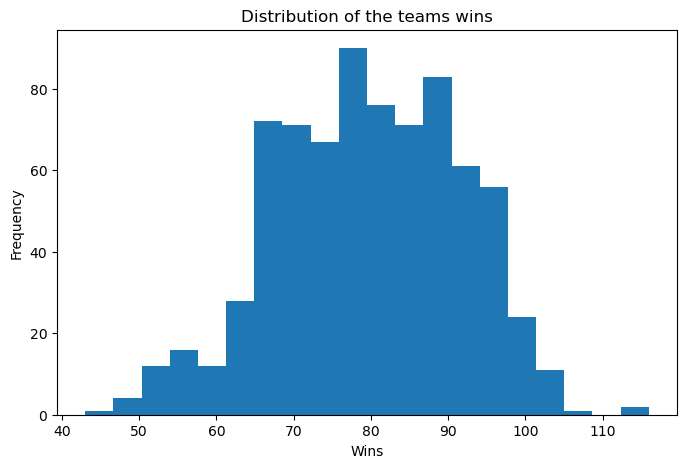

In [52]:
plt.figure(figsize = (8,5))
plt.hist(df["W"], bins=20)
plt.title("Distribution of the teams wins")
plt.xlabel("Wins")
plt.ylabel("Frequency")
plt.show()

Many teams have wins around the middle but few have lots more or lots less than the middle

In [53]:
df["payroll_mil"] = df["salary"]/1000000

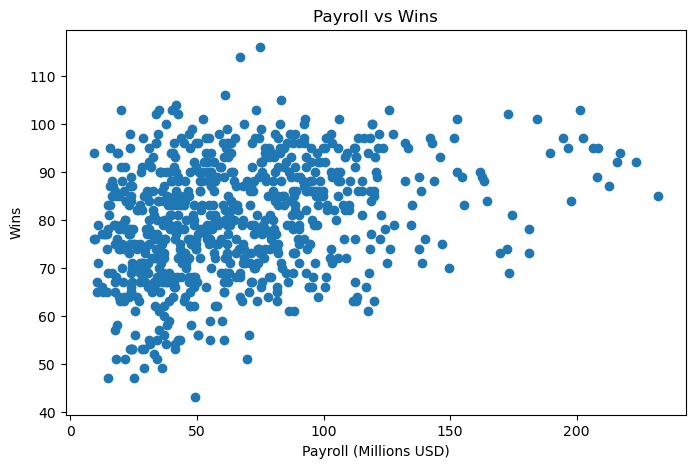

In [54]:
plt.figure(figsize = (8,5))
plt.scatter(df["payroll_mil"], df["W"])
plt.title("Payroll vs Wins")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Wins")
plt.show()

There is a positive correlation with higher salary comes avg more wins but there are some outliers who still dont follow the correlation

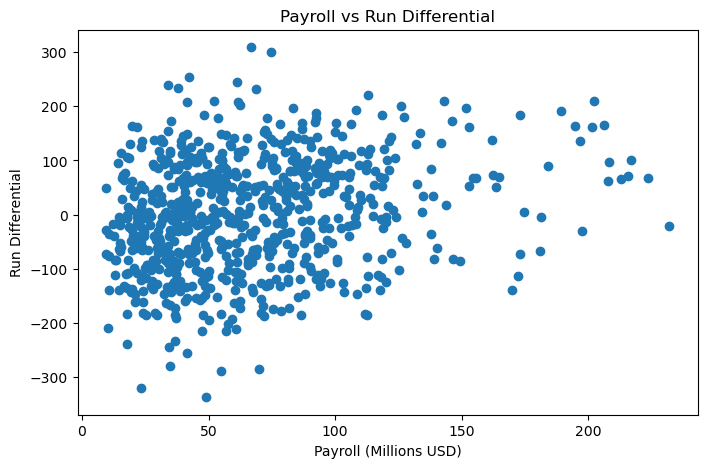

In [55]:
plt.figure(figsize = (8,5))
plt.scatter(df["payroll_mil"], df["run_diff"])
plt.title("Payroll vs Run Differential")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Run Differential")
plt.show()

In [56]:
df[["salary", "W", "L", "ERA", "run_diff"]].corr()

,salary,W,L,ERA,run_diff
salary,1.000000,0.314511,-0.149147,-0.196417,0.246811
W,0.314511,1.000000,-0.688389,-0.566182,0.857643
L,-0.149147,-0.688389,1.000000,0.480119,-0.856844
ERA,-0.196417,-0.566182,0.480119,1.000000,-0.593661
run_diff,0.246811,0.857643,-0.856844,-0.593661,1.000000


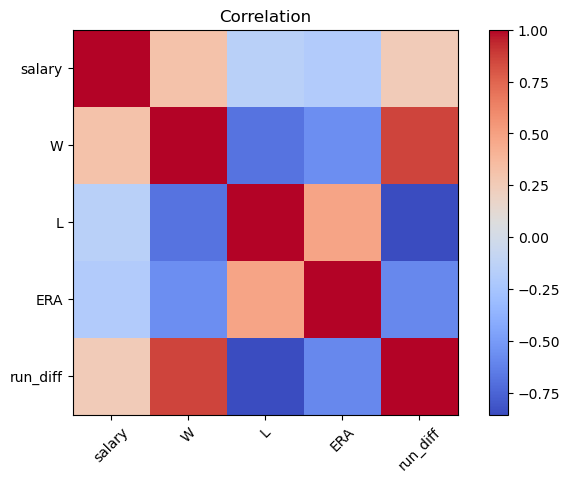

In [57]:
plt.figure(figsize = (8,5))
plt.imshow(df[["salary", "W", "L", "ERA", "run_diff"]].corr(), cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.title("Correlation")
plt.xticks(range(5), ["salary", "W", "L", "ERA", "run_diff"], rotation=45)
plt.yticks(range(5), ["salary", "W", "L", "ERA", "run_diff"])
plt.show()

In [58]:
features = df[["payroll_mil", "W","ERA", "run_diff"]]
features.head()

,payroll_mil,W,ERA,run_diff
130,14.555501,65,4.58,-139
131,9.680084,76,4.04,-29
132,20.558333,88,3.72,35
133,21.720000,80,3.79,-16
134,9.491500,94,3.61,49


The features were standardized before clustering this makes sure that each variable of wins, era, payroll, etc all contribute to clustering equally.

In [59]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [60]:
inertia =[]
for k in range(1,10):
    model = KMeans(n_clusters=k,random_state =42, n_init=10)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

Elbow method was used to determine appropriate number of clusters for K-means clustering

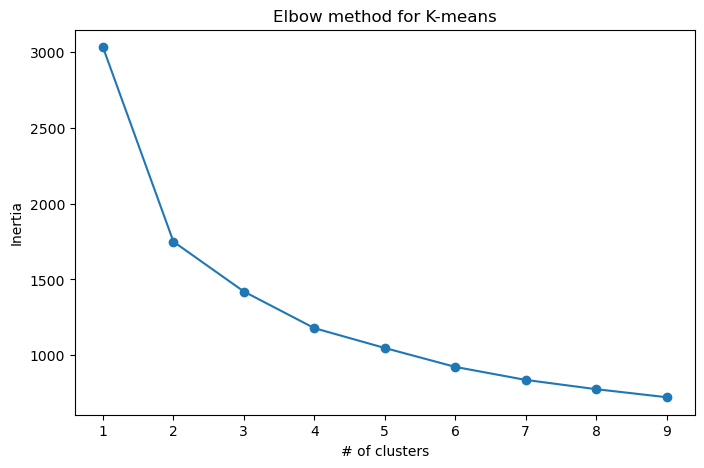

In [61]:
plt.figure(figsize = (8,5))
plt.plot(range(1,10), inertia, marker="o")
plt.title("Elbow method for K-means")
plt.xlabel("# of clusters")
plt.ylabel("Inertia")
plt.show()

The graph shows us that the rate of improvement slows around 2 but drastically slows about k = 3 showing us to use k =3 for clustering

In [62]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_data)

C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Clustering was applied to group teams based on payrolls and performance eadch team/year assigned to 1/3 clusters

In [63]:
df.head()

,yearID,teamID,W,L,R,RA,ERA,salary,run_diff,payroll_mil,cluster
130,1990,ATL,65,97,682,821,4.58,14555501,-139,14.555501,1
131,1990,BAL,76,85,669,698,4.04,9680084,-29,9.680084,2
132,1990,BOS,88,74,699,664,3.72,20558333,35,20.558333,2
133,1990,CAL,80,82,690,706,3.79,21720000,-16,21.720000,2
134,1990,CHA,94,68,682,633,3.61,9491500,49,9.491500,2


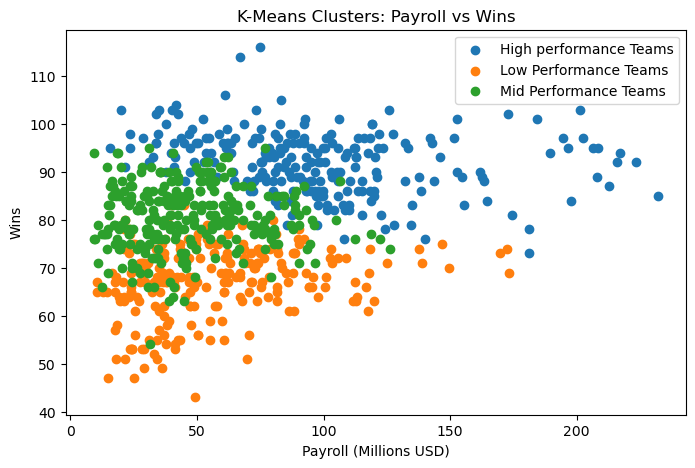

In [64]:
plt.figure(figsize = (8,5))

cluster_labels = {
    0:"High performance Teams",
    1:"Low Performance Teams",
    2:"Mid Performance Teams"
}
for cluster_num in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_num]
    plt.scatter(cluster_data["payroll_mil"], cluster_data["W"], label=cluster_labels[cluster_num])

plt.title("K-Means Clusters: Payroll vs Wins")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Wins")
plt.legend()
plt.show()

This gives the final K-means Clustering analysis 

In [65]:
df.groupby("cluster")[["salary", "W", "ERA", "run_diff"]].mean()
cluster_summary = df.groupby("cluster")[["payroll_mil", "W", "ERA", "run_diff"]].mean()

print(cluster_summary)

         payroll_mil          W       ERA    run_diff
cluster                                              
0          97.356294  91.928270  3.817637   99.421941
1          56.700177  67.106996  4.777490 -111.115226
2          46.815007  80.424460  4.175468   12.366906


The clustering analysis identified 3 groups of mlb teams.
Cluster 0 shows astrong performing teams withj higher avg winsand positive run differetial.
Cluster 1 shows weaker performing teams with low win avg and negative run differential.
Cluster 2 shows mid level teams typically in the middle for avg wins and near 0 for run differential.


In [66]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(scaled_data, df["cluster"])
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2542321059929351


Silhoutte score shows and measures how well-seperated the clusters are and having approximately .25 means it was okay clustering which is expected for this type of data set

In [67]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [68]:
X = df[["payroll_mil", "W", "ERA", "run_diff"]]
y = df["cluster"]

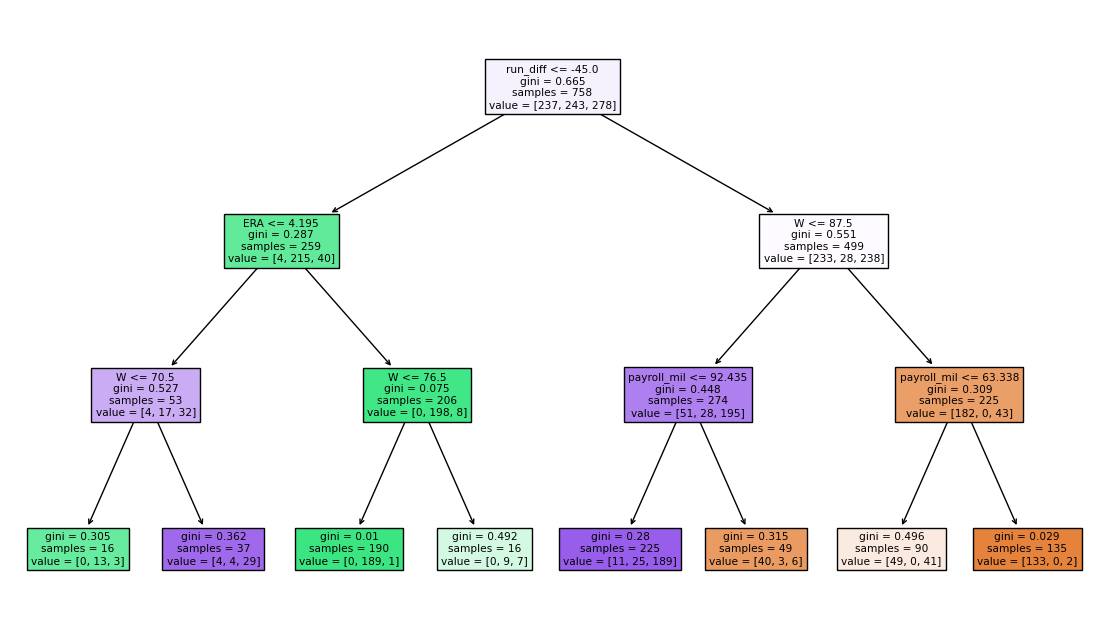

In [69]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)
plt.figure(figsize=(14,8))
plot_tree(tree,feature_names=X.columns, filled = True)
plt.show()


Decision tree was used as an interpretation tool to explain clusters identified by K-means. The first split was based specifcially on run differential, show team performance was the key tool to catagories. Additional splits would be based of ERA and wins. This tree shows how stronger performing teams tend to seperate clearly from weaker performing teams.

The clustering results revealed meaningful patterns, but with limitations to analysis. The silhoutte score shower medium cluster saeperation instead of perfect defined groups. This is expected with real life values and data. Another limitation was the inflation wasn't adjusted for.

This project showed how clustering and classification techniques can show the positive overall correlation between team payroll for a year and the overall performance they did for that given year usually being higher salary, higher performance outcome.